## Configuración para Google Colab

Si estás usando Google Colab ejecuta esto primero:

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk openpyxl spacy
!python -m spacy download en_core_web_sm

# en la sección "Cargar Dataset", cambia 'data/...' por '/content/...'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 100.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [53]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.8 MB/s eta 0:00:00


In [11]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Middle Term Test 2 - COVID-19 Fake News Detection

## 1.1 Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist
from nltk.util import ngrams
from nltk.text import Text
import spacy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic

## 1.2 Cargar Dataset

In [3]:
# cargar datasets test, train, val, y text_with_labels
''' train_df = pd.read_excel('data/Constraint_English_Train.xlsx')
val_df = pd.read_excel('data/Constraint_English_Val.xlsx')
test_df = pd.read_excel('data/Constraint_English_Test.xlsx')
text_with_labels = pd.read_excel('data/english_test_with_labels.xlsx') '''

train_df = pd.read_excel('/content/Constraint_English_Train.xlsx')
val_df = pd.read_excel('/content/Constraint_English_Val.xlsx')
test_df = pd.read_excel('/content/Constraint_English_Test.xlsx')
text_with_labels = pd.read_excel('/content/english_test_with_labels.xlsx')

# info basica
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# mostrar tweets completos
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

train_df.head(15)

Train shape: (6420, 3)
Validation shape: (2140, 3)
Test shape: (2140, 2)


,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In general the discrepancies in death counts between different sources are small and explicable. The death toll stands at roughly 100000 people today.,real
1,2,States reported 1121 deaths a small rise from last Tuesday. Southern states reported 640 of those deaths. https://t.co/YASGRTT4ux,real
2,3,Politically Correct Woman (Almost) Uses Pandemic as Excuse Not to Reuse Plastic Bag https://t.co/thF8GuNFPe #coronavirus #nashville,fake
3,4,#IndiaFightsCorona: We have 1524 #COVID testing laboratories in India and as on 25th August 2020 36827520 tests have been done : @ProfBhargava DG @ICMRDELHI #StaySafe #IndiaWillWin https://t.co/Yh3ZxknnhZ,real
4,5,Populous states can generate large case counts but if you look at the new cases per million today 9 smaller states are showing more cases per million than California or Texas: AL AR ID KS KY LA MS NV and SC. https://t.co/1pYW6cWRaS,real
5,6,"Covid Act Now found ""on average each person in Illinois with COVID-19 is infecting 1.11 other people. Data shows that the infection growth rate has declined over time this factors in the stay-at-home order and other restrictions put in place."" https://t.co/hhigDd24fE",real
6,7,If you tested positive for #COVID19 and have no symptoms stay home and away from other people. Learn more about CDC’s recommendations about when you can be around others after COVID-19 infection: https://t.co/z5kkXpqkYb. https://t.co/9PaMy0Rxaf,real
7,8,Obama Calls Trump’s Coronavirus Response A Chaotic Disaster https://t.co/DeDqZEhAsB,fake
8,9,"???Clearly, the Obama administration did not leave any kind of game plan for something like this.??�",fake
9,10,Retraction—Hydroxychloroquine or chloroquine with or without a macrolide for treatment of COVID-19: a multinational registry analysis - The Lancet https://t.co/L5V2x6G9or,fake


Como analisis a simple vista podemos ver que hay tweets mas cortos y otros mas largos pero la mayoria usan hastags y enlaces a fuentes. Tambien podemos ver que algunos usan cifras para describir lo que dicen, en esta pequeña muestra todos lo que usan cifras son reales pero vamos a analizar mas cosas a continuación.

## 1.3 EDA (analisis linguistico)

### 1.3.1 Análisis de distribución de clases

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
df = train_df.copy()
df = df[['tweet', 'label']]

In [6]:
# distribución de clases
df['label'].value_counts()

,count
label,
real,3360
fake,3060


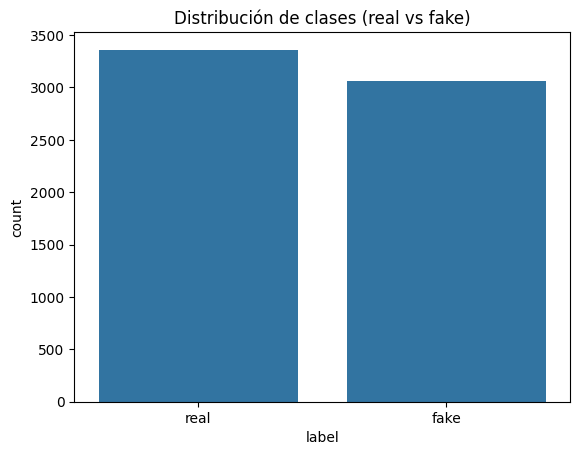

In [7]:
sns.countplot(data=df, x='label')
plt.title("Distribución de clases (real vs fake)")
plt.show()

Hay mas reales que falsos, esto nos dara problemas en comparaciones numericas ya que seran descompensadas.

### 1.3.4 Tokenización + stopwords + frecuencia

In [8]:
stop_words = set(stopwords.words("english"))

In [9]:
def preprocess_nltk(text):
    tokens = word_tokenize(text)
    return [w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words]

In [12]:
df['tokens'] = df['tweet'].astype(str).apply(preprocess_nltk)
df[['tweet', 'tokens']].head()

,tweet,tokens
0,The CDC currently reports 99031 deaths. In general the discrepancies in death counts between different sources are small and explicable. The death toll stands at roughly 100000 people today.,"[cdc, currently, reports, deaths, general, discrepancies, death, counts, different, sources, small, explicable, death, toll, stands, roughly, people, today]"
1,States reported 1121 deaths a small rise from last Tuesday. Southern states reported 640 of those deaths. https://t.co/YASGRTT4ux,"[states, reported, deaths, small, rise, last, tuesday, southern, states, reported, deaths, https]"
2,Politically Correct Woman (Almost) Uses Pandemic as Excuse Not to Reuse Plastic Bag https://t.co/thF8GuNFPe #coronavirus #nashville,"[politically, correct, woman, almost, uses, pandemic, excuse, reuse, plastic, bag, https, coronavirus, nashville]"
3,#IndiaFightsCorona: We have 1524 #COVID testing laboratories in India and as on 25th August 2020 36827520 tests have been done : @ProfBhargava DG @ICMRDELHI #StaySafe #IndiaWillWin https://t.co/Yh3ZxknnhZ,"[indiafightscorona, covid, testing, laboratories, india, august, tests, done, profbhargava, dg, icmrdelhi, staysafe, indiawillwin, https]"
4,Populous states can generate large case counts but if you look at the new cases per million today 9 smaller states are showing more cases per million than California or Texas: AL AR ID KS KY LA MS NV and SC. https://t.co/1pYW6cWRaS,"[populous, states, generate, large, case, counts, look, new, cases, per, million, today, smaller, states, showing, cases, per, million, california, texas, al, ar, id, ks, ky, la, ms, nv, sc, https]"


### 1.3.2 Longitud del tweet

In [13]:
df['tweet_length'] = df['tokens'].apply(len)

In [14]:
# estadisticas descriptivas por clase
df.groupby('label')['tweet_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3060.0,12.724837,18.592957,1.0,8.0,11.0,15.0,835.0
real,3360.0,16.702083,5.931704,2.0,12.0,17.0,21.0,34.0


La media es de 12 en los falsos y 16 en los verdaderos, no es mucha diferencia.

La longitud maxima de los tweets falsos es mas grande (de 835) pero vamos a ver porque a continuación:

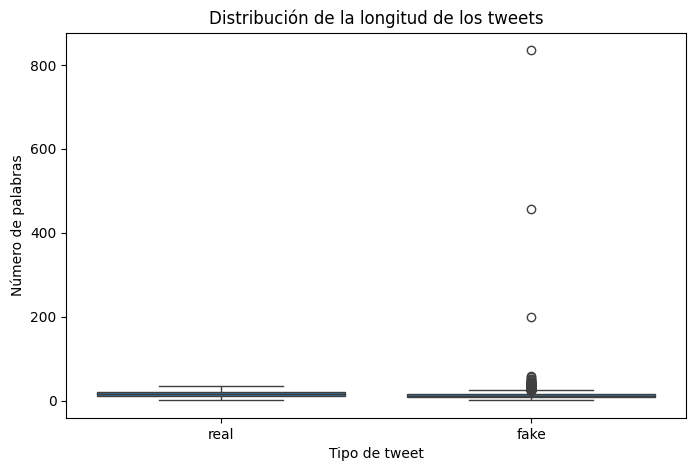

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='tweet_length')
plt.title("Distribución de la longitud de los tweets")
plt.ylabel("Número de palabras")
plt.xlabel("Tipo de tweet")
plt.show()

Los tweets falsos tienen varios outliners o anomalias que son tweets con cantidad de palabras estremadamente grandes.

In [16]:
df[df['tweet_length'] > 100][['tweet', 'label']].head()

tweet  \
270   Amoxi" Capsule made in US is the only medicine that can completely cure COVID-19.\nEgyptian Health Minister arrive in Italy with secret coronavirus cure.\n Dr Charles Lieber a Harvard professor has been arrested in the USA for manufacturing the coronavirus and selling it to China. A video news report from WCVB a TV station in Boston Massachusetts is shared with the Facebook post.\nMountain Matterhorn in Switzerland was lit in three colours of Indian flag as a token of gratitude to India for sending Hydroxychloroquine.\nAl-Azhar Imam said he is considering exceptions on Ramadan fasting as the research says that the mouth must be kept wet to prevent COVID-19\n Japanese Nobel Tasuku Honjo says coronavirus was created in the Wuhan laboratory\nA man collapses in 5 minutes after showing COVID-19 symptoms in India.\nCelebrities spreading misinformation about coronavirus and the Janata curfew in India.\n Multiple posts shared repeatedly on Facebook and Twitter since March 2020 claim that Israel has reported zero deaths from the novel coronavirus which causes the disease COVID-19. The posts also claim Israeli citizens have protected themselves from COVID-19 by drinking a remedy of hot water lemon and baking soda which purportedly “kills” the virus.\n CDC suddenly lost 30000 deaths from coronavirus from its data thus proving the virus is not as serious as it seems.\nPhotos of coronavirus patients being treated on the road in Italy.\nIndian actor Shah Rukh Khan donated money to Pakistan to fight coronavirus and did not help India at all.\nRussian President Vladimir Putin has ordered Russia’s population to stay at home for 15 days or face five years in jail.\nIndian Army has set-up a 1000 bed quarantine facility in Rajasthan's Barmer.\nLeonardo Da Vinci Hospital a COVID-19 reference hospital in Fortaleza Brazil is empty. A video "proves" there was no one at the areas open to the public.\n President Trump's claim that he inherited no ventilators from the Obama administration.\nAn audio where an unidentified person links the virus that causes COVID-19 with the massive flu vaccination campaign.\nBlack body bags being referred to as deaths in New York and the reason a lockdown is essential.\nMustard oil prevents a person from getting infected with COVID-19.\nNorth Carolina’s health department is "telling hospitals that if they decide to do elective surgeries they won’t be eligible to receive (protective equipment) from the state.”\n After coronavirus pandemic Chinese president said it's China's time to lead the world.\nThe nurses that Boris Johnson claimed saved his life are not registered in the UK.\nA claim that India’s Ministry of Home Affairs has made it a “punishable offense” for citizens to publish posts on social media about the novel coronavirus has been shared repeatedly on Facebook Twitter and WhatsApp.\n Says Nancy Pelosi was “caught trying to include abortion funding in bill to combat coronavirus.”\nA video of a man rebuking foreigners has been viewed thousands of times on social media alongside a claim that the Guinean government has ordered the arrest of all Chinese nationals in the country while awaiting the safe return of Guineans from China.\n The U.S. is the only country on earth that is protesting being locked down.\nPhoto of Kurnool MLA (Hafeez Khan) making a nurse to touch the feet of a religious head in Viswabharathi Medical College who had to come to the COVID-19 quarantine facility.\nNew York State Governor shows data that proves that isolation is ineffective against COVID-19.\nHomeopathic product Oscillococcinum protects against COVID-19.\nCDC admitted to lying about COVID-19 death stats.\nNotice for preparing emergency drugs was released on social media for alumni of Seoul National University College of Medicine.\nBelgian doctors turn their back on WHO director.\nDr. Li Wenliang (the Chinese whistleblower doctor) has proposed that drinking tea can cure COVID-19.\nAny person arrested for violating lockd

Ahora al verlos mejor parecen muchos tweets separados por \n como si no fueran tweets individuales si no recopilatorios o resumen de bulos como son fake. 

### 1.3.3 Diversidad léxica

In [17]:
def lexical_diversity(tokens):
    return len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

In [19]:
tokens_real = [w for tokens in df[df['label'] == 'real']['tokens'] for w in tokens]
tokens_fake = [w for tokens in df[df['label'] == 'fake']['tokens'] for w in tokens]
lex_real = lexical_diversity(tokens_real)
lex_fake = lexical_diversity(tokens_fake)

print("Lexical diversity (REAL):", lex_real)
print("Lexical diversity (FAKE):", lex_fake)

Lexical diversity (REAL): 0.11076462517151053
Lexical diversity (FAKE): 0.22006780009245466


Los tweets falsos tienen mas diversidad lexica, probablemente los reales se repiten entre ellos al ser las noticias reales igual por eso tienen vocabulario compartido.

### 1.3.5 Limpieza de URLs (https)
Necesitamos limpiar los token https debidos a que surgen a partir de los enlaces.

In [20]:
def preprocess_nltk_clean(text):
    tokens = word_tokenize(text)
    return [
        w.lower()
        for w in tokens
        if w.isalpha()
        and w.lower() not in stop_words
        and w.lower() != "https"
    ]

In [21]:
df['tokens_clean'] = df['tweet'].astype(str).apply(preprocess_nltk_clean)

### 1.3.6 Frecuencia de palabras (por clases)
Aqui vamos a identificar que palabras se relacionan mas por cada clase

In [22]:
tokens_real_clean = [w for tokens in df[df['label'] == 'real']['tokens_clean'] for w in tokens]
tokens_fake_clean = [w for tokens in df[df['label'] == 'fake']['tokens_clean'] for w in tokens]

In [23]:
fdist_real_clean = FreqDist(tokens_real_clean)
fdist_fake_clean = FreqDist(tokens_fake_clean)

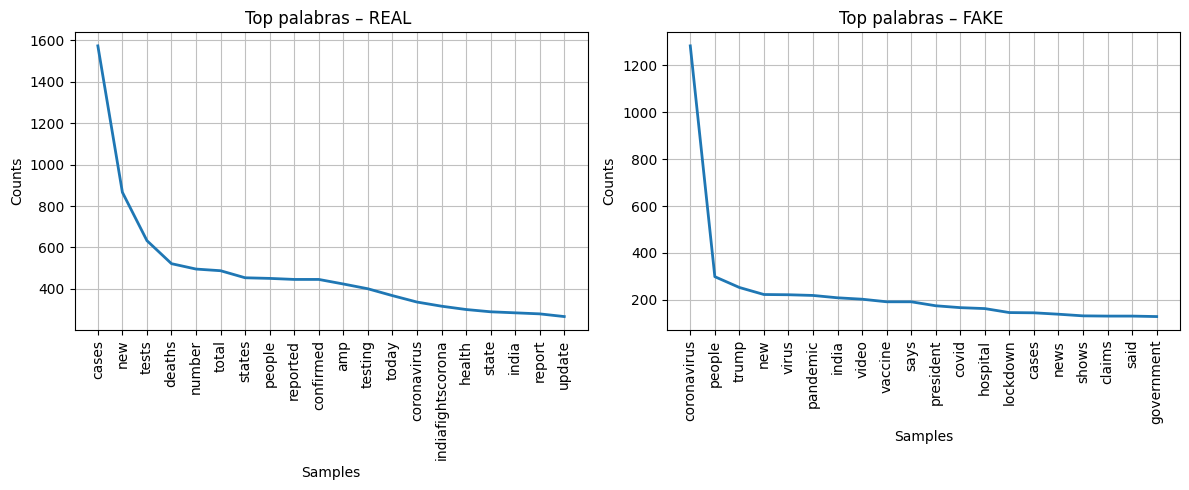

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
fdist_real_clean.plot(20, cumulative=False)
plt.title("Top palabras – REAL ")

plt.subplot(1,2,2)
fdist_fake_clean.plot(20, cumulative=False)
plt.title("Top palabras – FAKE ")

plt.tight_layout()
plt.show()

Podemos ver que en fake predomina `coronavirus` como la palabra top mas de 1200 veces. Y en los reales `cases` probablemente son tweets que informan de los nuevos casos o confirmados.

Y a simple vista podemos ver que las demas palabras en los falsos aparecen de forma uniforme no hay mas predominancia, es decir son ricos linguisticamente. Mientras en los verdaderos si se ve mucho mas `new`, `tests` o `deaths`.

### 1.3.7 N-grams

In [26]:
bigrams_real = list(ngrams(tokens_real_clean, 2))
bigrams_fake = list(ngrams(tokens_fake_clean, 2))

trigrams_real = list(ngrams(tokens_real_clean, 3))
trigrams_fake = list(ngrams(tokens_fake_clean, 3))

In [27]:
fdist_bi_real = FreqDist(bigrams_real)
fdist_bi_fake = FreqDist(bigrams_fake)

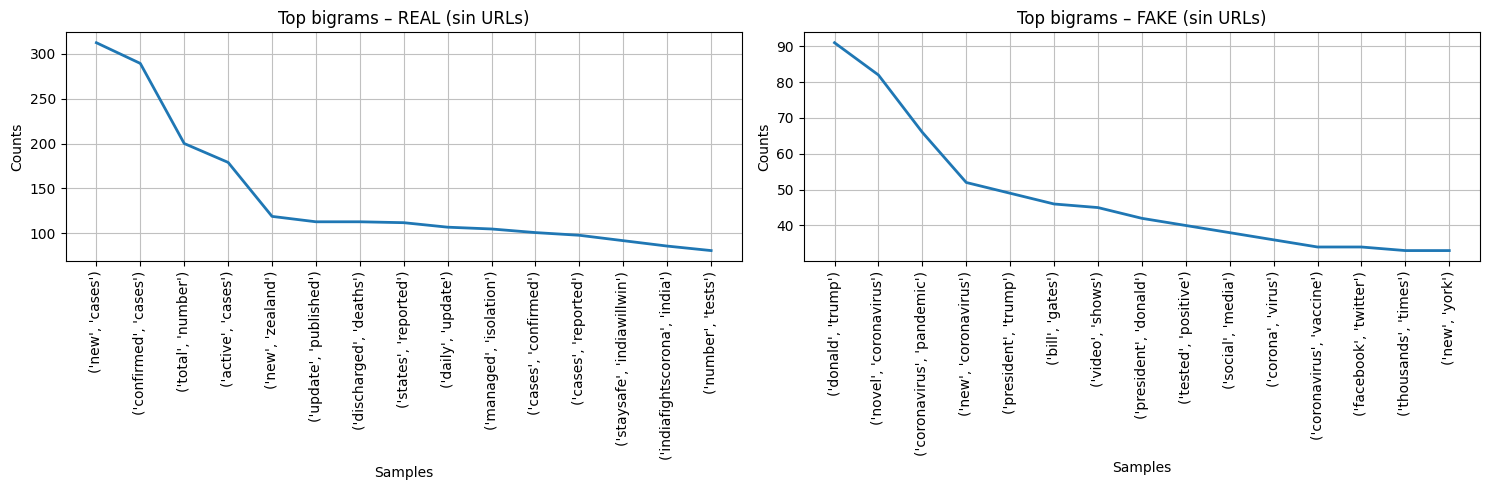

In [28]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
fdist_bi_real.plot(15, cumulative=False)
plt.title("Top bigrams – REAL (sin URLs)")

plt.subplot(1,2,2)
fdist_bi_fake.plot(15, cumulative=False)
plt.title("Top bigrams – FAKE (sin URLs)")

plt.tight_layout()
plt.show()

En n-grams podemos ver que el par mas común en reales es `new, cases` y `confirmed, cases` lo que nos puede decir que los reales estan mas relacionados con los casos nuevos o confirmados y por ejemplo con `total, number` podemos ver lo que vimos al principio que estarian mas relacionados con poner los cifras.

En cuanto a los falsos lo segundo mas común es un enlace y despues la palabra coronavirus probablente son hastags que se suelen poner al final justo despues de los enlaces como #coronavirus, como tecer tenemos `donald, trump` con casi 100 apariciones.

Tambien tenemos `coronavirus, pandemic` en los fake que intuimos que pueden ser hastags con el objetivo de llamar la atención y alarmar.

### 1.3.8 POS tagging

Siguiendo con los analisis linguisticos ahora veremos analisis por pos tags, es decir tipos de palabras.
Como puede haber mas tweets reales que falsos no usaremos numeros si no que haremos un conteo y mostraremos porcentajes.

In [29]:
def pos_distribution(text):
    doc = nlp(text)
    return [token.pos_ for token in doc if token.is_alpha]

In [30]:
df['pos_tags'] = df['tweet'].astype(str).apply(pos_distribution)

In [31]:
# por clases
pos_real = [p for tags in df[df['label'] == 'real']['pos_tags'] for p in tags]
pos_fake = [p for tags in df[df['label'] == 'fake']['pos_tags'] for p in tags]
from collections import Counter

# Conteos
pos_real_counts = Counter(pos_real)
pos_fake_counts = Counter(pos_fake)

# Totales
total_pos_real = sum(pos_real_counts.values())
total_pos_fake = sum(pos_fake_counts.values())

# Frecuencias relativas
pos_real_freq = {k: v / total_pos_real for k, v in pos_real_counts.items()}
pos_fake_freq = {k: v / total_pos_fake for k, v in pos_fake_counts.items()}

In [32]:
pos_df = pd.DataFrame({
    'REAL': pd.Series(pos_real_freq),
    'FAKE': pd.Series(pos_fake_freq)
}).fillna(0)

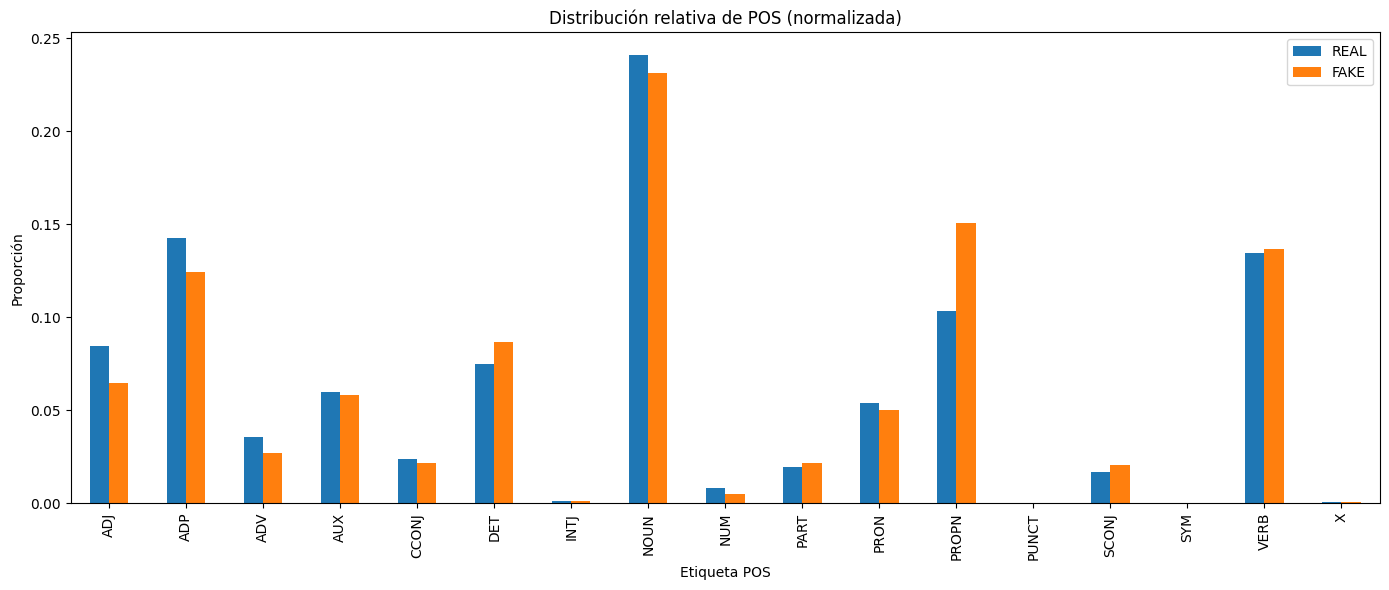

In [33]:
pos_df.plot(kind='bar', figsize=(14,6))
plt.title("Distribución relativa de POS (normalizada)")
plt.ylabel("Proporción")
plt.xlabel("Etiqueta POS")
plt.legend()
plt.tight_layout()
plt.show()

Podemos ver que como era esperable predominan los sustantivos de similar forma en ambos, donde podemos ver la mayor diferencias es en pronombres propios ahi los fake predominan por encima de los verdaderos.

Quizas esto de los pronombres propios es porque se tiende a usar un lenguaje mas personal y discursos mas emocionales o persuasivos.

### 1.3.9 Named Entity Recognition (NER)
Es como pos tags pero con entidades, pero usaremos nlp para clasificar los tokens en cosas del mundo real y compararemos (usando porcentajes).

In [34]:
def extract_entities(text):
    doc = nlp(text)
    return [ent.label_ for ent in doc.ents]

df['entities'] = df['tweet'].astype(str).apply(extract_entities)

In [35]:
entities_real = [e for ents in df[df['label'] == 'real']['entities'] for e in ents]
entities_fake = [e for ents in df[df['label'] == 'fake']['entities'] for e in ents]

In [36]:
ent_real_counts = Counter(entities_real)
ent_fake_counts = Counter(entities_fake)

total_ent_real = sum(ent_real_counts.values())
total_ent_fake = sum(ent_fake_counts.values())

In [37]:
ent_real_freq = {k: v / total_ent_real for k, v in ent_real_counts.items()}
ent_fake_freq = {k: v / total_ent_fake for k, v in ent_fake_counts.items()}

In [38]:
ent_df = pd.DataFrame({
    'REAL': pd.Series(ent_real_freq),
    'FAKE': pd.Series(ent_fake_freq)
}).fillna(0)

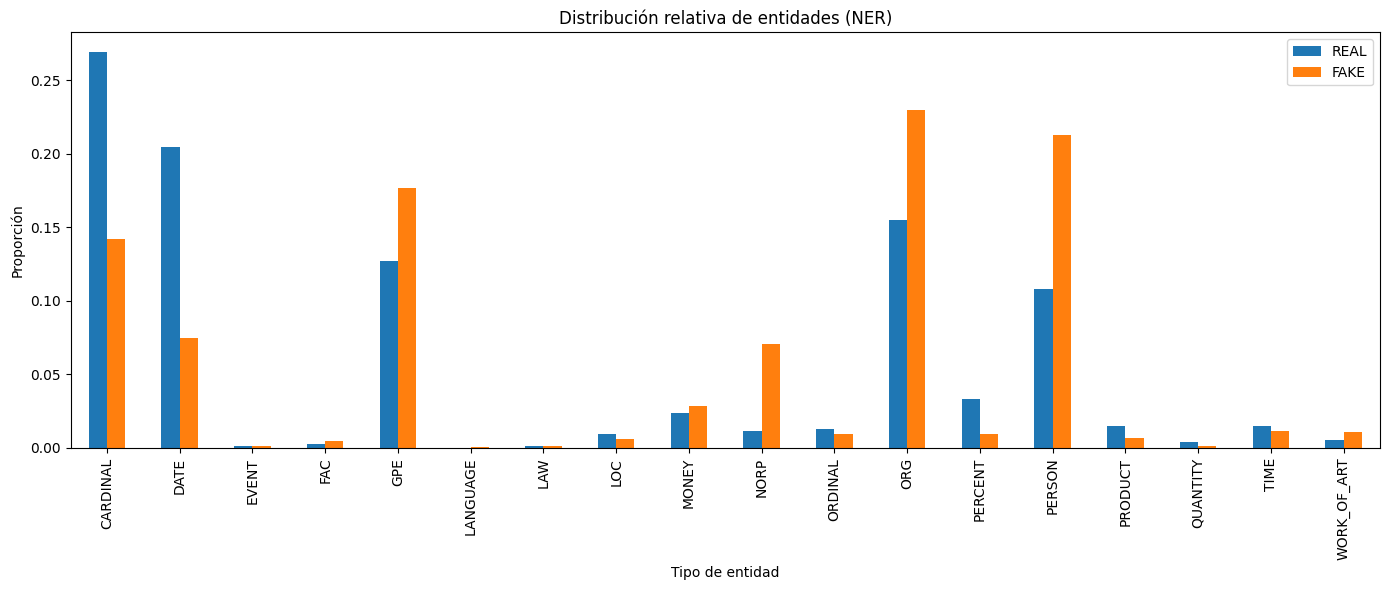

In [39]:
ent_df.plot(kind='bar', figsize=(14,6))
plt.title("Distribución relativa de entidades (NER)")
plt.ylabel("Proporción")
plt.xlabel("Tipo de entidad")
plt.legend()
plt.tight_layout()
plt.show()

Aqui hilamos con lo que dijimos al principio que los Reales tienen mas numeros o cifras que los Fake y esto se puede ver en la diferencia de la entidad `Cardinal`, también vemos que los reales suelen tener mas fechas.

En cuanto a los Fake suelen mas personas nombradas en sus tweets igual es un mecanismo para llamar la atención como vimos con trump en los n-grams y tambien predominan en ORG que son organizaciones tambien por lo mismo para llamar la atención seguramente.

Y podemos ver una predominancia muy clara en NORP aunque es minima comparada con otros porcentajes pero serian como grupos politicos o religiosos lo cual es lógico en tweets falsos.

### 1.3.10 Hashtags y menciones

In [40]:
def count_hashtags(text):
    return sum(1 for w in text.split() if w.startswith("#"))

def count_mentions(text):
    return sum(1 for w in text.split() if w.startswith("@"))

df['num_hashtags'] = df['tweet'].apply(count_hashtags)
df['num_mentions'] = df['tweet'].apply(count_mentions)

In [41]:
df.groupby('label')[['num_hashtags', 'num_mentions']].mean()

,num_hashtags,num_mentions
label,,
fake,0.508170,0.181046
real,1.052976,0.427381


Por ultimo en este analisis, podemos ver que los tweets reales tienen mayor cantidad de hastags y de menciones

## 2 Busqueda No informada (BERTopic)
En los apartados anteriores hemos realizado un analisis linguistico de el dataset para identificar patrones latentes globales en el conjunto de tweets.

Pero ahora haremos **topic modelling**, una técnica de aprendizaje no supervisado cuyo objetivo es descubrir grupos de documentos que comparten temas semánticos similares sin las etiquetas de Real/Fake.

### 2.1 Limpiar los datos
Necesitamos el texto limpio y sin los labels (real/fake)

In [44]:
import re

def clean_text(text):
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # eliminar URLs
    text = re.sub(r"[^a-zA-Z\s]", " ", text)        # solo letras
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df['cleaned_tweet'] = train_df['tweet'].astype(str).apply(clean_text)

### 2.2 Representación vectorial: embeddings

In [45]:
from sentence_transformers import SentenceTransformer

documents = train_df['cleaned_tweet'].tolist()

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embedding_model.encode(documents, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/201 [00:00<?, ?it/s]

### 2.3 Método del codo adaptado a nlp
Como no hay `k` fijo vamos a probar distintos n_components en UMAP y medir calidad del clustering con silhouette score.
Nota: aclarar que es este metodo no es necesario ya que no tiene la misma efectividad que con k-means

In [47]:
sil_scores = []
components_range = [2, 5, 10, 15, 20]

for n in components_range:
    umap_tmp = UMAP(
        n_neighbors=15,
        n_components=n,
        metric='cosine',
        random_state=42
    )
    reduced = umap_tmp.fit_transform(embeddings)

    cluster_tmp = HDBSCAN(min_cluster_size=15)
    labels_tmp = cluster_tmp.fit_predict(reduced)

    # ignoramos ruido (-1)
    mask = labels_tmp != -1
    if len(set(labels_tmp[mask])) > 1:
        score = silhouette_score(reduced[mask], labels_tmp[mask])
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


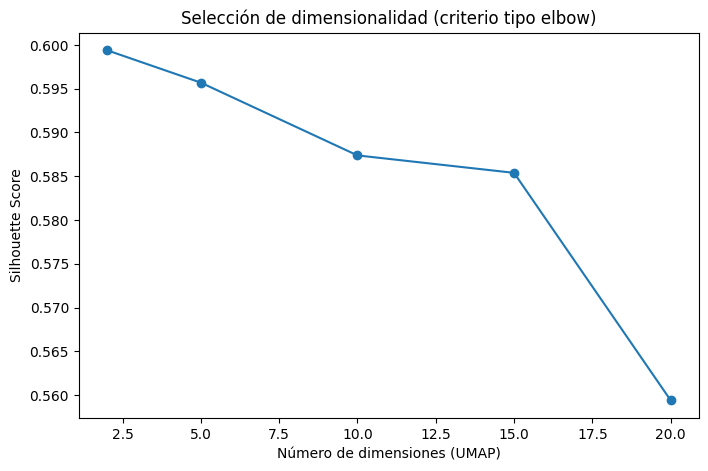

In [48]:
plt.figure(figsize=(8,5))
plt.plot(components_range, sil_scores, marker='o')
plt.xlabel("Número de dimensiones (UMAP)")
plt.ylabel("Silhouette Score")
plt.title("Selección de dimensionalidad (criterio tipo elbow)")
plt.show()

No se ve un codo claro como con k-means pero podemos sacar algo en claro y es que a partir de 15.0 hay un empeoramiento claro podemos decir que a partir de cierto número de dimensiones añadir más información introduce ruido y empeora la separabilidad de los clusters.

Podemos tomar como valor 10.0 porque está en la “meseta” de la curva.

### 2.4 Reducción de dimensionalidad final (UMAP)

In [49]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=10,
    metric='cosine',
    random_state=42
)

### 2.5 HDBSCAN

In [51]:
cluster_model = HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

### 2.6 Representación de topics

In [55]:
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


### 2.6 Construcción del modelo BERTopic

In [57]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=True,
    language="english",
    verbose=True
)

### 2.7 Entrenamiento no supervisado

In [58]:
topics, probs = topic_model.fit_transform(documents)

2025-12-25 21:29:31,172 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2025-12-25 21:31:14,427 - BERTopic - Embedding - Completed ✓
2025-12-25 21:31:14,428 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-25 21:31:24,741 - BERTopic - Dimensionality - Completed ✓
2025-12-25 21:31:24,755 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-25 21:31:26,154 - BERTopic - Cluster - Completed ✓
2025-12-25 21:31:26,160 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-25 21:31:26,582 - BERTopic - Representation - Completed ✓


### 2.8 Análisis inicial de los clusters

In [59]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2777,-1_coronavirus_health_amp_people,"[coronavirus, health, amp, people, home, pandemic, says, india, positive, patients]","[coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths, coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths, coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths]"
1,0,237,0_water_drinking_cure_alcohol,"[water, drinking, cure, alcohol, drink, urine, cure coronavirus, kill, salt, cures]","[claim cow urine dung could treat covid assam legislator haripriya fact such claims only add to misinformation fear mongering should fight disease scientifically anant bhanhealth researcher no preventive med cure yet who, claim cow urine dung could treat covid assam legislator haripriya fact such claims only add to misinformation fear mongering should fight disease scientifically anant bhan health researcher no preventive med cure yet who, claim cow urine dung could treat covid assam legislator haripriya fact such claims only add to misinformation fear mongering should fight disease scientifically anant bhan health researcher no preventive med cure yet who]"
2,1,234,1_restrictions_uk_boris_england,"[restrictions, uk, boris, england, lockdown, boris johnson, johnson, london, follow live, scotland]","[the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of coronavirus the health secretary has told sky news, the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of covid health secretary matthancock has told sky news to read more click here, pm boris johnson says office workers who can work from home should do so and adds that all pubs bars and restaurants in england should operate table service only and must close at pm from thursday updates on latest covid restrictions in england]"
3,2,223,2_trump_donald trump_donald_president,"[trump, donald trump, donald, president, donaldtrump, president trump, americans, pandemic, obama, realdonaldtrump]","[cindy mccain becomes second republican to join joe biden s transition team i too am widow of distinguished us military officer would not affiliate w biden deep ties to adversary ccp that stuck down americans in launched bioweapon covid on us soil, says donald trump tweeted i ordered the treasury secretary to send checks to americans first however we will go through your social media history from the last years and search for any post with notmypresident in it i wouldn t think of offending you with a check if i m not your president maga, president donald trump tweeted i ordered the treasury secretary to send checks to americans first however we will go through your social media history from the last years and search for any post with notmypresident in it i wouldn t think of offending you with a check if i m not your president maga]"
4,3,161,3_nigeria_covid reported_reported nigeria_ncdc,"[nigeria, covid reported, reported nigeria, ncdc, lagos, covid nigeria, chikwe, cases covid, nigeria discharged, pm th]","[eight new cases of covid have been reported in nigeria in lagos in the fct and in kaduna state as at pm th april there are confirmed cases of covid reported in nigeria thirty three have been discharged with five deaths, forty nine new cases of covid have been reported in lagos in fct in kano in ogun in oyo in ekiti as at pm th april there are confirmed cases of covid reported in nigeria discharged deaths takeresponsibility, eleven new cases of covid have been reported in lagos state as at pm th april there are confirmed cases of covid reported in niger

Como podemos ver nos da un total de 59 topics mas el topic -1 que son: tweets ambiguos, tweets demasiado cortos o tweets que no encajan claramente en ningún grupo y simplemente hdbscan no los fuerza a ningún topic.

Lo que vemos es:
- Topic: nombre del topic
- Count: número de tweets en ese topic
- Representation: palabras mas representativas
-	Representative_Docs: tweets prototipo

Los tweets sin topic (-1) son 2777 y los topic mas grandes son `0_water_drinking_cure_alcohol, 1_restrictions_uk_boris_england y 2_trump_donald trump_donald_president` con mas 200 tweets.

### 2.9 Visualización de los topics

In [60]:
topic_model.visualize_topics()

Podemos ver que hay muchos grupos diferenciados, los grupos mas grandes son donde esta el topic -1 que son cosas mas generales como relacionadas con el origen del covid o nombres que se le da (sars, cov..).

El segundo grupo mas grande es mas relacionado con politica (trump, belinda..) y desinformacion.

Hay dos grupos mediados: uno es mas asociado a lo cientifico o datos (records, reported, confirmed..) y el otro mas general como de instuticiones (schools, hospitals..)

Y otros grupos pequeños como uno relacionado con medidas (mascarillas, ropa) y otro que se relaciona mas con paises (italia, brazil..).